# 01 — Exploratory Data Analysis & Preprocessing

**Goal.** Load the raw CICIDS2017 CSVs, clean them, run a rich exploratory pass,
and persist the artifacts (`train/val/test`, `scaler`, `label_map`,
`feature_names`) the downstream notebooks and `src/inference.py` consume.

The heavy lifting lives in `src/preprocessing.py` so the **exact same**
cleaning is re-used at runtime by `SmartTIDS_Predictor`.


In [2]:
import sys, os, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `import src` work from /notebooks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

from src import config as cfg
from src.preprocessing import (
    load_raw_directory, clean_dataframe, drop_rare_classes, save_json,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load raw CSVs

In [3]:
data = load_raw_directory(cfg.RAW_DIR)
print("Raw shape:", data.shape)
data.head(3)


Raw shape: (3119345, 86)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,33.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109.0,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,9174.311927,9174.311927,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52.0,52.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,19230.769230,19230.769230,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2. Class distribution (raw)

In [4]:
counts = data[cfg.LABEL_COL].value_counts()
fig = px.bar(
    x=counts.index, y=counts.values, log_y=True,
    labels={"x": "class", "y": "count (log scale)"},
    title="CICIDS2017 — raw class distribution",
)
fig.show()
print(counts)


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


## 3. Cleaning

* strip duplicate / identifier columns
* coerce `Flow Bytes/s` to numeric
* drop NaN / Inf rows
* drop classes with too few samples to learn (< 50)


In [5]:
data = clean_dataframe(data)
data = drop_rare_classes(data)
print("After cleaning:", data.shape)
print("Classes kept:", data[cfg.LABEL_COL].nunique())


After cleaning: (2827808, 79)
Classes kept: 12


## 4. Distribution sanity checks for a few key features

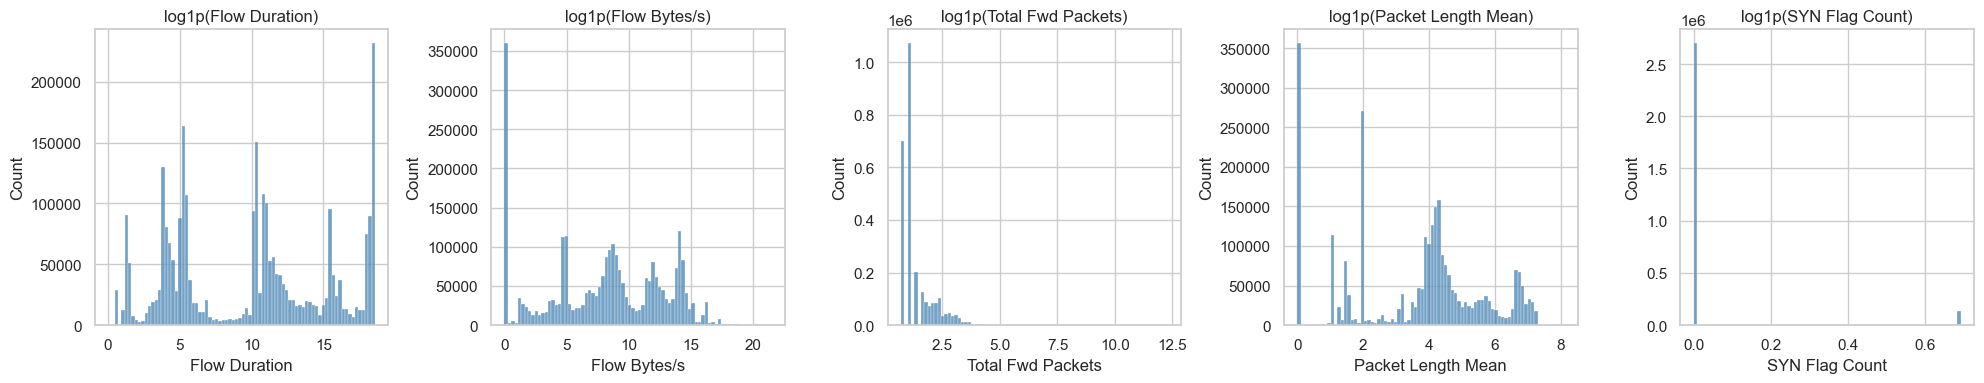

In [6]:
key_feats = ["Flow Duration", "Flow Bytes/s", "Total Fwd Packets",
             "Packet Length Mean", "SYN Flag Count"]
fig, axes = plt.subplots(1, len(key_feats), figsize=(4*len(key_feats), 4))
for ax, f in zip(axes, key_feats):
    if f in data.columns:
        sns.histplot(np.log1p(data[f].clip(lower=0)), bins=80, ax=ax, color="steelblue")
        ax.set_title(f"log1p({f})")
plt.tight_layout()
plt.show()


## 5. Correlation among numeric features

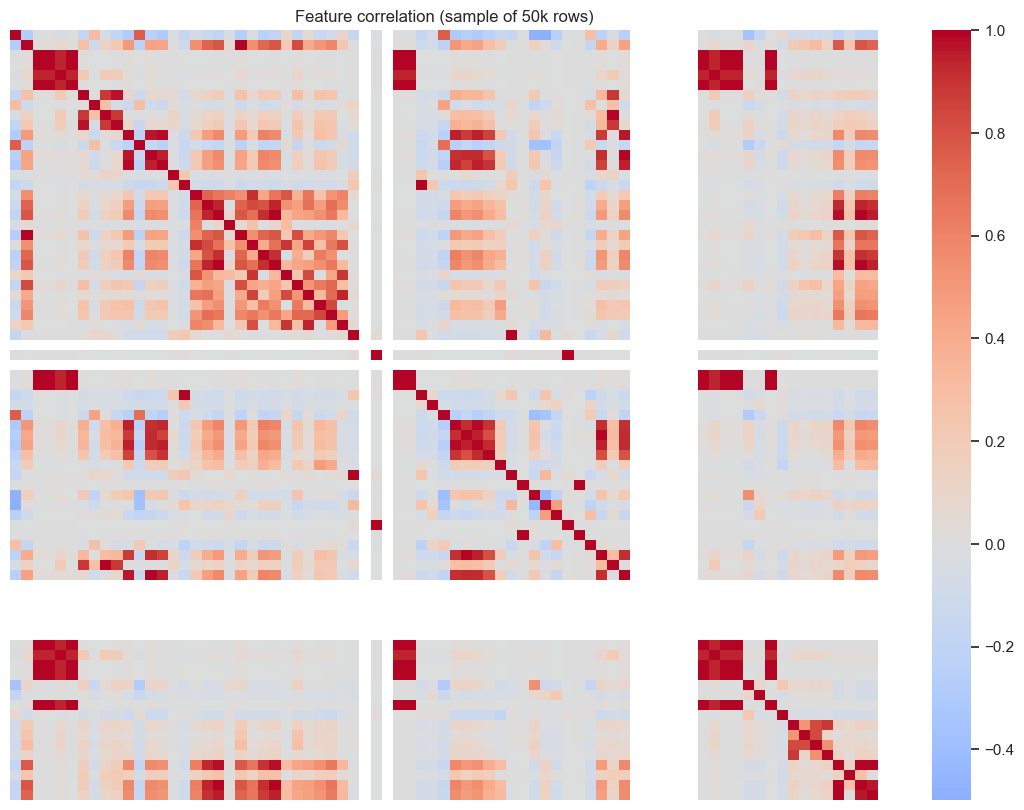

In [7]:
num = data.select_dtypes(include=np.number)
corr = num.sample(n=min(50_000, len(num)), random_state=cfg.RANDOM_STATE).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar=True, xticklabels=False, yticklabels=False)
plt.title("Feature correlation (sample of 50k rows)")
plt.show()


## 6. Encode labels & persist label map

In [8]:
le = LabelEncoder()
data[cfg.ENCODED_COL] = le.fit_transform(data[cfg.LABEL_COL])
label_map = {int(i): cls for i, cls in enumerate(le.classes_)}

cfg.FEATURES_DIR.mkdir(parents=True, exist_ok=True)
save_json(label_map, cfg.LABEL_MAP_FILE)

for i, c in label_map.items():
    print(f"  {i:2d} -> {c:<35} ({(data[cfg.ENCODED_COL]==i).sum():>9,} rows)")


   0 -> BENIGN                              (2,271,320 rows)
   1 -> Bot                                 (    1,956 rows)
   2 -> DDoS                                (  128,025 rows)
   3 -> DoS GoldenEye                       (   10,293 rows)
   4 -> DoS Hulk                            (  230,124 rows)
   5 -> DoS Slowhttptest                    (    5,499 rows)
   6 -> DoS slowloris                       (    5,796 rows)
   7 -> FTP-Patator                         (    7,935 rows)
   8 -> PortScan                            (  158,804 rows)
   9 -> SSH-Patator                         (    5,897 rows)
  10 -> Web Attack  Brute Force            (    1,507 rows)
  11 -> Web Attack  XSS                    (      652 rows)


## 7. Feature list

In [9]:
drop_for_features = {cfg.LABEL_COL, cfg.ENCODED_COL, "source_file"}
feature_cols = [c for c in data.columns if c not in drop_for_features]
save_json(feature_cols, cfg.FEATURE_NAMES_FILE)
print(f"Saved {len(feature_cols)} feature names -> {cfg.FEATURE_NAMES_FILE}")


Saved 77 feature names -> D:\smart_ids\data\cicids2017\features\feature_names.json


## 8. Time-aware split (70 / 15 / 15)

CICIDS2017 was captured chronologically across 5 working days. We honour that
order rather than shuffling so the test set reflects "future" traffic.


In [10]:
day_order = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
]
data["_day"] = data["source_file"].apply(
    lambda f: day_order.index(f) if f in day_order else 999
)
data = data.sort_values("_day").drop(columns=["_day", "source_file"]).reset_index(drop=True)

n = len(data)
tr_end, va_end = int(n*0.70), int(n*0.85)
train_df = data.iloc[:tr_end].reset_index(drop=True)
val_df   = data.iloc[tr_end:va_end].reset_index(drop=True)
test_df  = data.iloc[va_end:].reset_index(drop=True)

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")


train: 1,979,465  val: 424,171  test: 424,172


## 9. Fit StandardScaler on train and persist it

In [11]:
scaler = StandardScaler()
scaler.fit(train_df[feature_cols].astype(np.float32).values)

cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, cfg.SCALER_FILE)
print("Saved scaler ->", cfg.SCALER_FILE)


Saved scaler -> D:\smart_ids\models\scaler.joblib


## 10. Persist splits

In [12]:
cfg.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(cfg.PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(cfg.PROCESSED_DIR / "val.csv",     index=False)
test_df.to_csv(cfg.PROCESSED_DIR / "test.csv",   index=False)
print("Splits saved to", cfg.PROCESSED_DIR)


Splits saved to D:\smart_ids\data\cicids2017\processed


---
**Outputs of this notebook**

| Artifact | Path |
|---|---|
| Train / val / test CSVs | `data/cicids2017/processed/` |
| Label map               | `data/cicids2017/features/label_map.json` |
| Feature names           | `data/cicids2017/features/feature_names.json` |
| Scaler                  | `models/scaler.joblib` |

Move on to **02_mlp_training.ipynb**.
